#### El experimento escogido es: /home/slozgom/personal/tfg_project/xperiments/experimentos_con_cnn/05_iid_complete

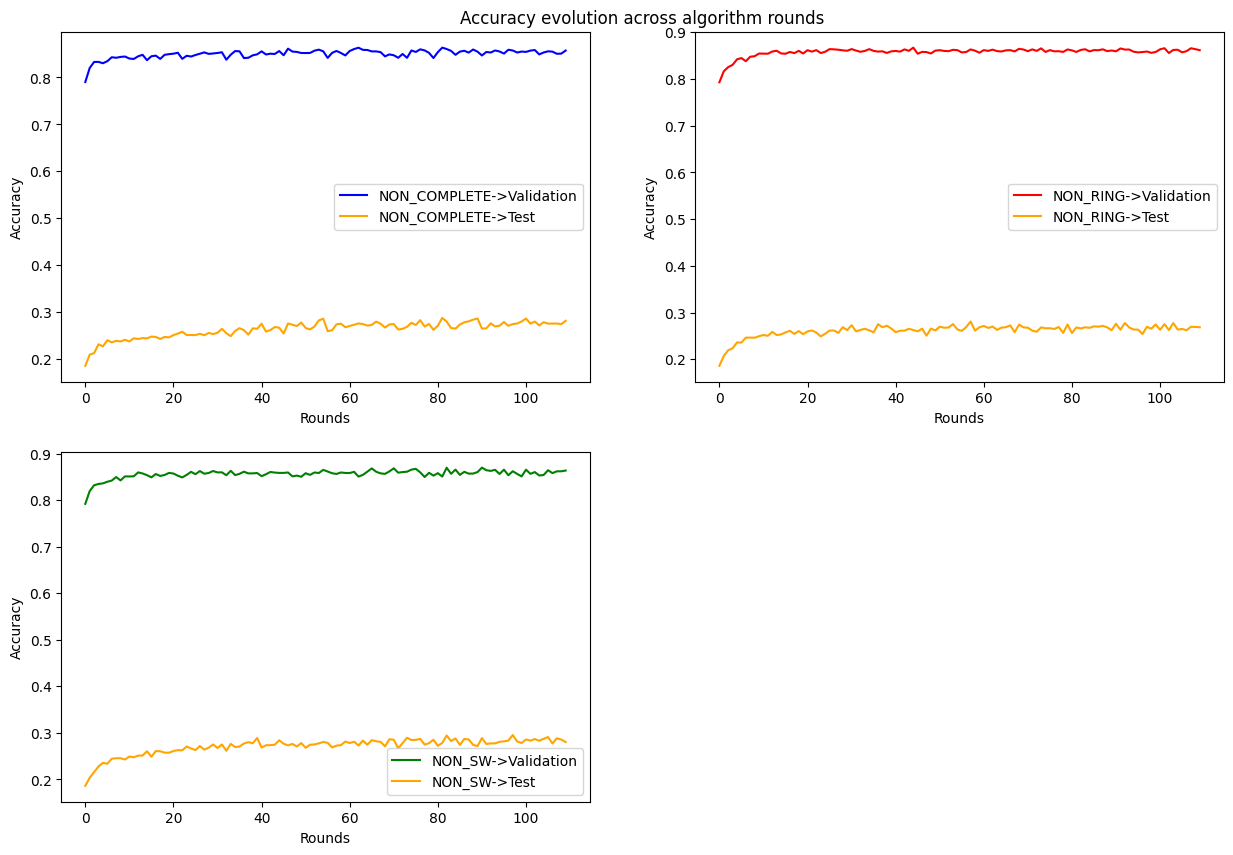

In [2]:
from typing import Iterable
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Let's try plots with 5 agents
NON_COMPLETE = Path("./xperiments/experimentos_con_cnn/10_non_complete/raw/")
NON_RING = Path("./xperiments/experimentos_con_cnn/10_non_ring/raw/")
NON_SW = Path("./xperiments/experimentos_con_cnn/10_non_sw/raw/")
PATHS = [NON_COMPLETE, NON_RING, NON_SW]
NAMES = ["NON_COMPLETE", "NON_RING", "NON_SW"]
COLORS = ["blue", "red", "green"]
SUBPLOT = 221

data = pd.read_csv(PATHS[0] / "nn_convergence.csv")
agents = data.agent.unique()
rounds = data.algorithm_round.unique()
epochs = data.epoch_or_iteration.unique()
layers = data.layer.unique()

# Usando varianza, con los valores inmediatamente después del consenso

plt.figure(figsize=(15,10))
plt.axis('off')
plt.title("Accuracy evolution across algorithm rounds")

for i, (path, name, color) in enumerate(zip(PATHS, NAMES, COLORS)):
    data = pd.read_csv(path / "nn_inference.csv")
    test_accuracies = []
    validation_accuracies = []
    for round in rounds:
        inference_data = data[(data.algorithm_round==round)]
        test_accuracy = np.mean(np.array([inference_data.test_accuracy]))
        validation_accuracy = np.mean(np.array([inference_data.validation_accuracy]))
        test_accuracies.append(test_accuracy)
        validation_accuracies.append(validation_accuracy)
        
    plt.subplot(SUBPLOT+i)
    plt.plot(validation_accuracies, label=f"{name}->Validation", color=color)
    plt.plot(test_accuracies, label=f"{name}->Test", color="orange")
    plt.xlabel("Rounds")
    plt.ylabel("Accuracy") 
    plt.legend(loc="best")

plt.show()

Duda: Qué diferencias hay en los experimentos? Entre iid_complete y non_complete

En primer lugar he querido probar a calcular y mostrar el “Convergence value”. Utilizando la columna weight de nn_convergence.csv, calculando la varianza de los weights de todos los agentes para cada ronda, en la 1a época, para cada capa y luego sumando todos los rmse. El resultado es el siguiente.

Lo esperado es que cada vez la suma de las varianzas se vaya haciendo menor conforme el paso de las épocas, ya que está habiendo convergencia por lo que los pesos se van igualando, als diferencias recortando.

El hecho de coger la varianza es ya que no sabemos el valor real al que van a converger, aunque se podría hacer a posteriori. Cogiendo de referenca los valores de las rondas finales.

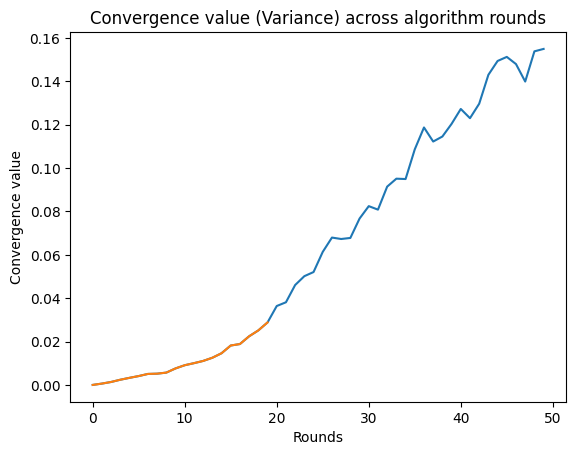

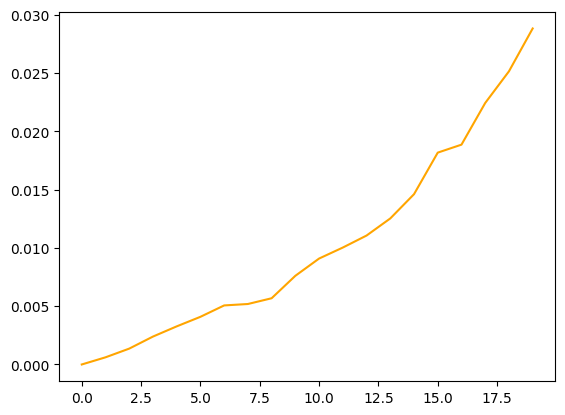

In [24]:
# Usando varianza, con los valores inmediatamente después del consenso

data = pd.read_csv(PATH / "nn_convergence.csv")
agents = data.agent.unique()
rounds = data.algorithm_round.unique()
epochs = data.epoch_or_iteration.unique()
layers = data.layer.unique()

alg_variances = []
description = "PRE-TRAIN"
epoch = 1
for round in rounds:
    agents_data = data[(data.algorithm_round==round) & (data.epoch_or_iteration==epoch) & (data.description==description)]
    layer_variances = []
    for layer in agents_data.layer.unique():
        layer_data = agents_data[(agents_data.layer == layer)]
        weights_variance = np.var(layer_data.weight)
        layer_variances.append(weights_variance)
    variance_sum = np.sum(np.array(layer_variances))
    alg_variances.append(variance_sum)
    
plt.figure()
plt.title("Convergence value (Variance) across algorithm rounds")
plt.xlabel("Rounds")
plt.ylabel("Convergence value")
plt.plot(alg_variances)
plt.plot(alg_variances[:20])
plt.show()
plt.plot(alg_variances[:20], color="orange")

No vemos los resultados esperados. Vemos resultados cercanos a 0 desde las primeras iteraciones. Podría significar convergencia prematura. Esto me da que pensar:

*¿Cuál es la forma actual de determinar que hay convergencia en el algoritmo?

*¿Esta media de los pesos realmente puede llegar a reflejar lo que buscamos, es decir, un indicador de convergencia?
- Debería poder, ya que si esta suma de varianzas es 0 indica que en cada capa la suma de los pesos es igual. Podríamos asumir que, por tanto, tenemos los mismos pesos. Esto puede ser erróneo ya que w1 = [0,4 0,4] y w2 = [0,2 0,6] tienen la misma media y son pesos distitnos. Haría falta más información para poder determinar la convergencia.
Yo en este gráfico veo aleatoriedad en la variable calculada.

#### Idea: En vez de solo disponer de la media de los pesos, sería interesante obtener la desviación típica, y comparar distribuciones de pesos en lugar de solo medias. Porque para el caso: 

w1 = [0,4 0,4] y w2 = [0,2 0,6] → Medias iguales pero distintos pesos, si nos basamos en la performance podríamos cometer un error ya que dependerá del caso de uso.

Añadiendo la desviación típica, abolimos este problema. Esto sirve considerando que los pesos siguen una distribución normal, podemos afirmarlo?

De todos modos, vamos a ver la performance. Un posible indicador de convergencia es la performance, es decir, si llegamos a tener todos los modelso prediciendo igual podriamos asumir que hay convergencia. A pesar de que dos modelos completamete distintos podrían dar el mismo resultado.
Esta es la evolución del Validation y del Test accuracy

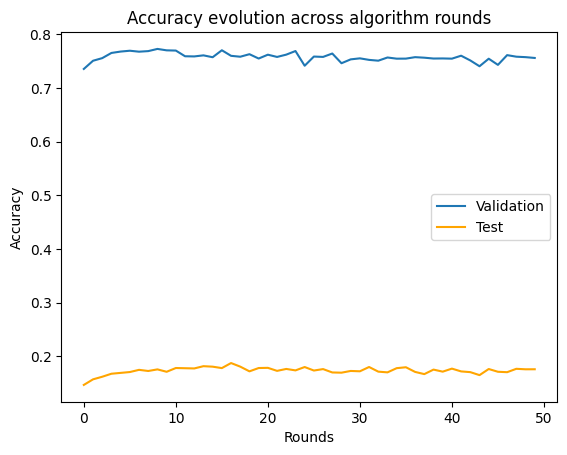

In [25]:
data = pd.read_csv(PATH / "nn_inference.csv")

test_accuracies = []
validation_accuracies = []
for round in rounds:
    inference_data = data[(data.algorithm_round==round)]
    test_accuracy = np.mean(np.array([inference_data.test_accuracy]))
    validation_accuracy = np.mean(np.array([inference_data.validation_accuracy]))
    test_accuracies.append(test_accuracy)
    validation_accuracies.append(validation_accuracy)
    
plt.figure()
plt.title("Accuracy evolution across algorithm rounds")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.plot(validation_accuracies, label="Validation")
plt.plot(test_accuracies, label="Test", color="orange")
plt.legend(loc="best")
plt.show()


Prácticamente tenemos los mismos valores de desempeño a lo largo de todo el algoritmo y no son muy altos.

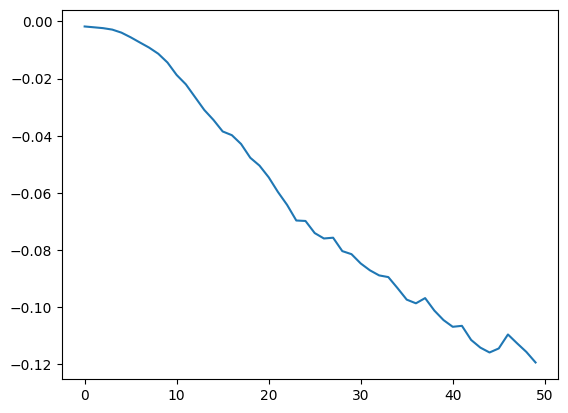

In [26]:
data = pd.read_csv(PATH / "nn_convergence.csv")

weights = []
for round in rounds:
    inference_data = data[(data.algorithm_round==round) & (data.agent=="a0")]
    mean_weights = np.mean(np.array([inference_data.weight]))
    weights.append(mean_weights)
plt.plot(weights)

*¿Hay correlación entre el desempeño y la suma de varianzas calculada?

In [27]:
from sklearn.preprocessing import MinMaxScaler

# create data

# scale features
alg_variances = alg_variances[1:]
test_accuracies = test_accuracies[:-1]

scaler = MinMaxScaler()
model = scaler.fit(list(zip(alg_variances, test_accuracies)))
scaled_data = model.transform(list(zip(alg_variances, test_accuracies)))

# print scaled features
sc_vars = [x[0] for x in scaled_data]
sc_accs = [x[1] for x in scaled_data]

df = pd.DataFrame({"vars": sc_vars, "accs": sc_accs})
df.corr(method="pearson")

,vars,accs
vars,1.000000,0.053479
accs,0.053479,1.000000


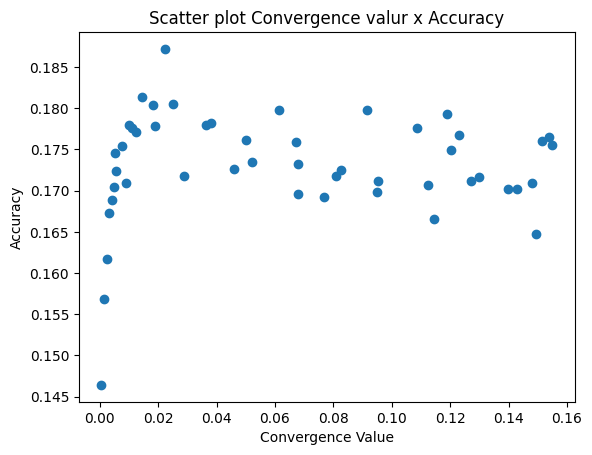

In [28]:
plt.title("Scatter plot Convergence valur x Accuracy")
plt.xlabel("Convergence Value")
plt.ylabel("Accuracy")
plt.scatter(alg_variances, test_accuracies)
plt.show()

Hay un poquito de correlación negativa, aunque no podemos considerarla como significativa.

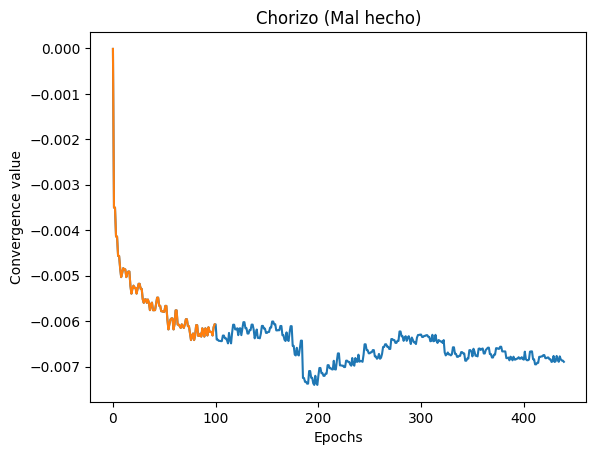

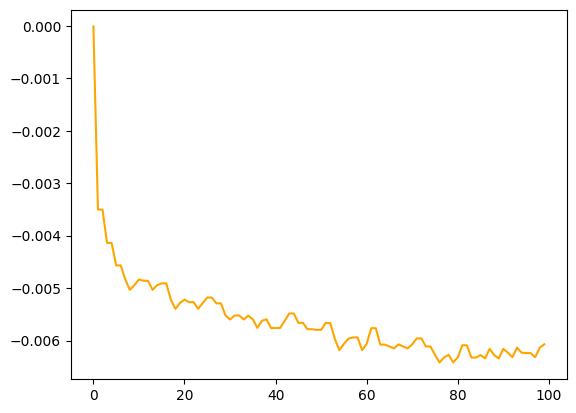

In [ ]:
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv(PATH / "nn_convergence.csv")
times = data.description.unique()
accuracies = []
data = data[(data.agent=="a0")]
for round in rounds:
    for epoch in epochs:
        inference_data = data[(data.algorithm_round==round) & (data.epoch_or_iteration==epoch)]
        epoch_weight = inference_data[(data.layer=="fc1.weight")]
        #print(len(epoch_weight))
        for i in epoch_weight.weight:
            accuracies.append(i)
plt.figure()
plt.title("Chorizo (Mal hecho)")
plt.xlabel("Epochs")
plt.ylabel("Convergence value")
plt.plot(accuracies)
plt.plot(accuracies[:100])
plt.show()
plt.plot(accuracies[:100], color="orange")

Básicamente indica como evoluciona el weight de una capa determinada, en este caso "fc1.weight". Todas las capas la media se va haciendo más negativa. Aquí está una posible prueba de que el weight no nos sirve para determinar convergenica, necesitamos más. O al revés, ya que que la media de pesos de todos los agente cambie de la misma forma podría ser interpretado como indicio de convergencia.

*Me he dado cuenta de que en cada ronda del algoritmo no hay siempre el mimso número de consensos.

Quizás el problema sea el experimento este. Sería mejor probar en un experimento con buenos resultados de performance.

- Probar un ejemplo mejor
- Probar distitno número de agentes
-

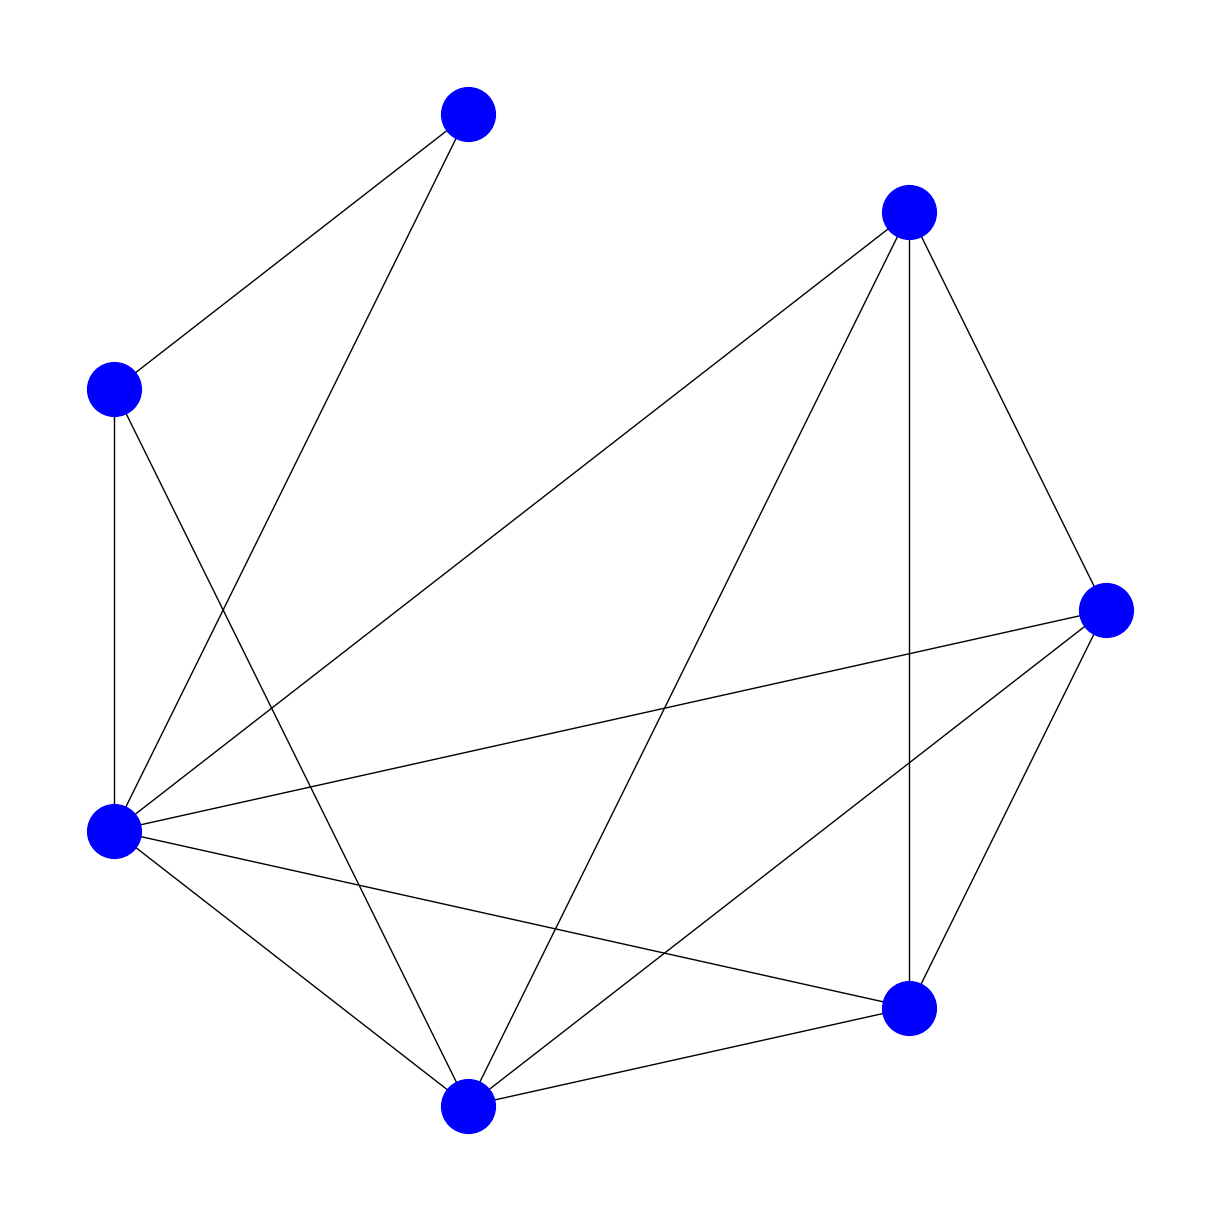

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.watts_strogatz_graph(n = 7, k = 4, p = 0.5)
pos = nx.circular_layout(G)

plt.figure(figsize = (12, 12))
nx.draw(G, pos, node_color = 'blue',
              node_size = 1500) 

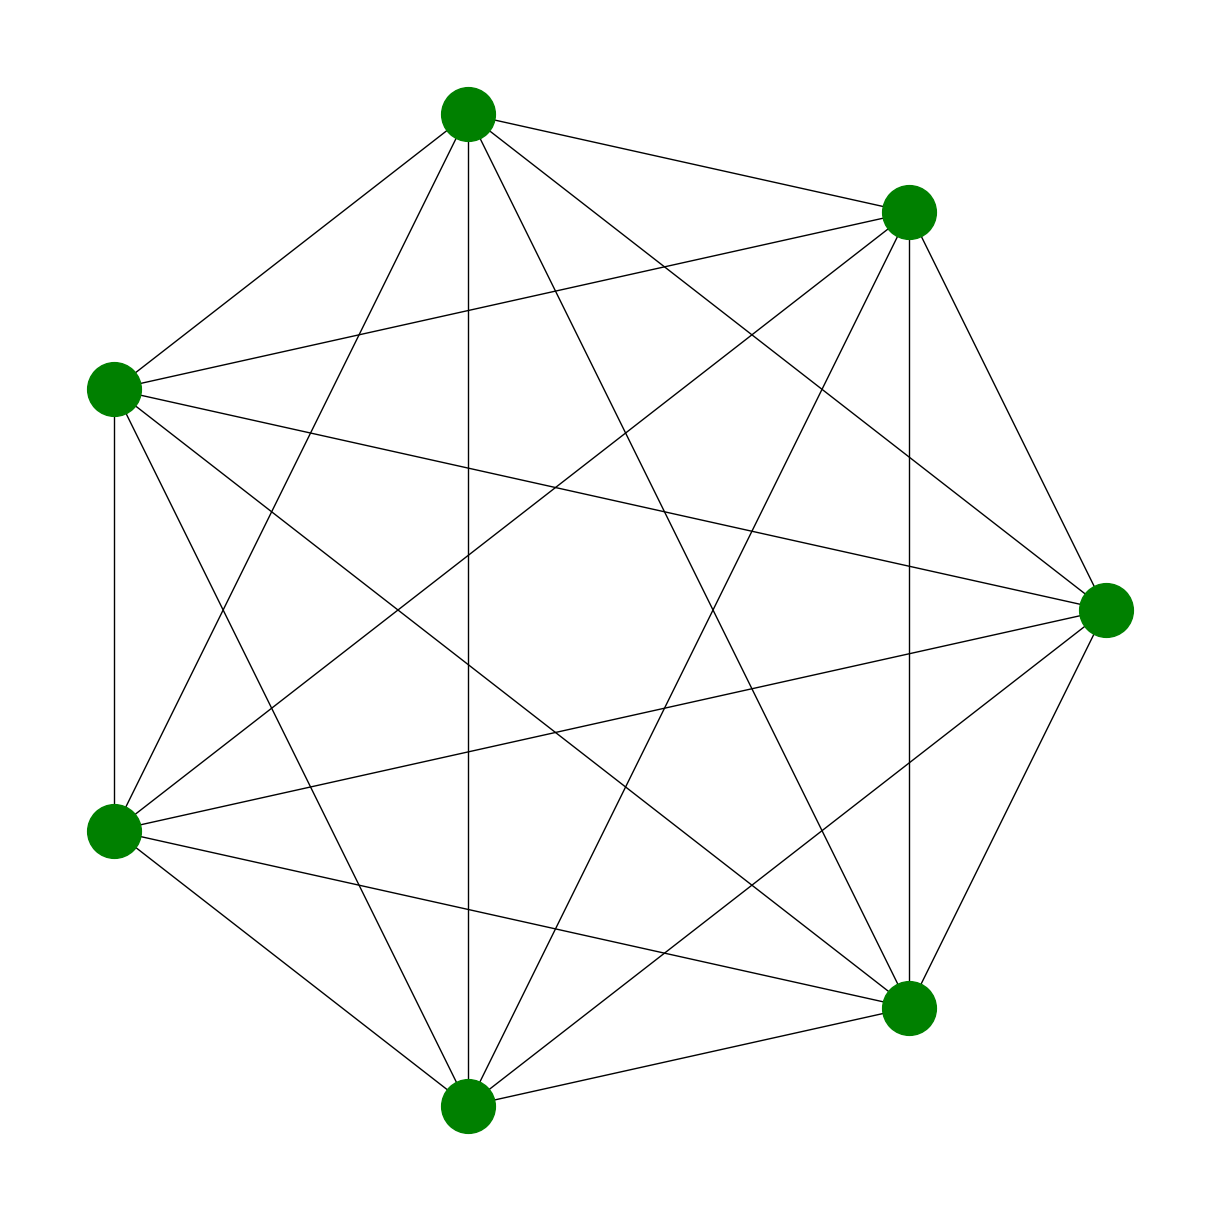

In [13]:
G = nx.complete_graph(7)
plt.figure(figsize = (12, 12)) 
nx.draw(G, pos, node_color = 'green',
              node_size = 1500) 

In [26]:
G = nx.cycle_graph(7)
plt.figure(figsize = (12, 12)) 
nx.draw(G, pos, node_color = 'red',
              node_size = 1500) 
import networkx
import matplotlib
import matplotlib.pyplot

#G = nx.cycle_graph(7)
# G = nx.watts_strogatz_graph(n = 7, k = 4, p = 0.5)
G = nx.complete_graph(7)
fig = matplotlib.pyplot.figure(figsize = (8, 8))
networkx.draw(G,pos, node_color = 'green',
              node_size = 1500, ax=fig.add_subplot())
if True: 
    # Save plot to file
    matplotlib.use("Agg") 
    fig.savefig("complete.svg")
else:
    # Display interactive viewer
    matplotlib.pyplot.show()